In [1]:
import os
import numpy as np
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
train_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_train_base.json'

In [3]:
test_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_test_base.json'

In [4]:
val_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_val_base.json'

In [5]:
with open(train_data_json_path, 'r') as f:
    train_data_json = json.load(f)
with open(val_data_json_path, 'r') as f:
    val_data_json = json.load(f)
with open(test_data_json_path, 'r') as f:
    test_data_json = json.load(f)

In [7]:
def json_to_df(json):
    rows=[]
    for org_id, info in json.items():
        label = info.get("label")
        batch = info.get("batch")
        timepoints = info.get("timepoints", {})

        for day_name, tp in timepoints.items():
            row = {
            "ID": org_id,          # your organoid id
            "batch": batch,
            "label": label,
            "DY": day_name,        # e.g. "Dy03"
            "img_path": tp.get("img_path"),
            "mask_path": tp.get("mask_path"),
            }

        # add metabolites
            for k, v in tp.get("metabolites", {}).items():
                row[k] = v

            rows.append(row)
    return pd.DataFrame(rows)
    

In [8]:
train_df = json_to_df(train_data_json)
test_df = json_to_df(test_data_json)
val_df = json_to_df(val_data_json)

In [12]:
trainval= pd.concat([train_df, val_df])

In [15]:
trainval['day'] = trainval['DY'].str.extract(r'(\d+)').astype(int)

# Compute growth features by ID or batch
trainval = trainval.sort_values(['ID', 'day'])
trainval['glucose_growth'] = trainval.groupby('ID')['GlucoseGlo_concentration_uM'].diff()
trainval['glutamate_growth'] = trainval.groupby('ID')['GlutamateGlo_concentration_uM'].diff()
trainval['LactateGlo_growth'] = trainval.groupby('ID')['LactateGlo_concentration_uM'].diff()
trainval['PyruvateGlo_growth'] = trainval.groupby('ID')['PyruvateGlo_concentration_uM'].diff()
trainval['MalateGlo_growth'] = trainval.groupby('ID')['MalateGlo_concentration_uM'].diff()



In [16]:
test_df['day'] = test_df['DY'].str.extract(r'(\d+)').astype(int)

# Compute growth features by ID or batch
test_df = test_df.sort_values(['ID', 'day'])
test_df['glucose_growth'] = test_df.groupby('ID')['GlucoseGlo_concentration_uM'].diff()
test_df['glutamate_growth'] = test_df.groupby('ID')['GlutamateGlo_concentration_uM'].diff()
test_df['LactateGlo_growth'] = test_df.groupby('ID')['LactateGlo_concentration_uM'].diff()
test_df['PyruvateGlo_growth'] = test_df.groupby('ID')['PyruvateGlo_concentration_uM'].diff()
test_df['MalateGlo_growth'] = test_df.groupby('ID')['MalateGlo_concentration_uM'].diff()

In [17]:
trainval.head(5)

,ID,batch,label,DY,img_path,mask_path,GlucoseGlo_concentration_uM,GlucoseGlo_initial_concentration,GlutamateGlo_concentration_uM,GlutamateGlo_initial_concentration,...,PyruvateGlo_concentration_uM,PyruvateGlo_initial_concentration,MalateGlo_concentration_uM,MalateGlo_initial_concentration,day,glucose_growth,glutamate_growth,LactateGlo_growth,PyruvateGlo_growth,MalateGlo_growth
997,BA1 96_1 A1,BA1,Acceptable,Dy03,/net/projects2/promega/data-analysis/output/in...,/net/projects2/promega/data-analysis/predictio...,9.827,19654.492,2.418,241.828,...,2.971,297.127,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
998,BA1 96_1 A1,BA1,Acceptable,Dy06,/net/projects2/promega/data-analysis/output/in...,/net/projects2/promega/data-analysis/predictio...,8.610,17219.547,2.445,244.454,...,2.373,237.303,NaN,NaN,6,-1.217,0.027,5.073,-0.598,NaN
999,BA1 96_1 A1,BA1,Acceptable,Dy08,/net/projects2/promega/data-analysis/output/in...,/net/projects2/promega/data-analysis/predictio...,10.589,21177.383,2.141,214.073,...,3.182,318.177,NaN,NaN,8,1.979,-0.304,-8.760,0.809,NaN
1000,BA1 96_1 A1,BA1,Acceptable,Dy10,/net/projects2/promega/data-analysis/output/in...,/net/projects2/promega/data-analysis/predictio...,11.864,23728.784,2.285,228.470,...,3.868,386.784,NaN,NaN,10,1.275,0.144,-0.368,0.686,NaN
1001,BA1 96_1 A1,BA1,Acceptable,Dy13,/net/projects2/promega/data-analysis/output/in...,/net/projects2/promega/data-analysis/predictio...,14.368,28735.301,0.893,89.260,...,2.306,230.649,-0.041,-0.816,13,2.504,-1.392,7.957,-1.562,NaN


In [26]:
def rolling_stats_per_id(
    df,
    id_col="ID",
    time_col="day",
    value_cols=("GlucoseGlo_concentration_uM", "GlutamateGlo_concentration_uM"),
    window=3,
    past_only=True,
    min_periods=1,
    ema=False
):
    df = df.copy()
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)

    for col in value_cols:
        s = df.groupby(id_col)[col]

        # base series for rolling stats (past-only if desired)
        base = s.shift(1) if past_only else s.transform(lambda x: x)

        roll = (base.groupby(df[id_col])
                    .rolling(window=window, min_periods=min_periods))

        df[f"{col}_roll_mean_w{window}"] = roll.mean().reset_index(level=0, drop=True)
        df[f"{col}_roll_std_w{window}"]  = roll.std().reset_index(level=0, drop=True)
        df[f"{col}_roll_min_w{window}"]  = roll.min().reset_index(level=0, drop=True)
        df[f"{col}_roll_max_w{window}"]  = roll.max().reset_index(level=0, drop=True)

        if ema:
            # compute EMA per ID, then flatten index to match df.index
            if past_only:
                ema_series = (s.apply(lambda x: x.shift(1)
                                                .ewm(span=window, adjust=False)
                                                .mean())
                                .reset_index(level=0, drop=True))
            else:
                ema_series = (s.apply(lambda x: x.ewm(span=window, adjust=False).mean())
                                .reset_index(level=0, drop=True))

            df[f"{col}_ema_w{window}"] = ema_series

    return df

In [27]:
#trainval = rolling_stats_per_id(
#    trainval,
#    id_col="ID",
#    time_col="day",   # make sure you have a 'day' column already
#    ema=True
#)

In [31]:
#test_df = rolling_stats_per_id(
#    test_df,
#    id_col="ID",
#    time_col="day",   # make sure you have a 'day' column already
#    ema=True
#)

In [16]:
# IDs only in dy6_train_df
#only_in_dy6 = dy6_train_df[~dy6_train_df['ID'].isin(dy28_train_df['ID'])]

# IDs only in dy28_test_df
#only_in_dy28 = dy28_train_df[~dy28_train_df['ID'].isin(dy6_train_df['ID'])]

NameError: name 'dy6_train_df' is not defined

In [39]:
from sklearn.model_selection import StratifiedGroupKFold
def metabolite_classifier(trainval, test_df, methodstr= "lgbm"):
    output_df = pd.DataFrame(columns=['DY', 'accuracy_score_value','precision_accept', 'precision_notaccept','recall_accept','recall_notaccept','f1-score_accept','f1-score_accept'])
    rows = []
    for days in np.unique(trainval.DY):
        print(days)
        selected_train_df = trainval[trainval['DY']==days]
        selected_test_df = test_df[test_df['DY']==days]
        #print(selected_train_df)
        #print(len(selected_test_df))
    #per_day_metabolite_survey_data = pd.merge(survey_label_selected, selected_meta_df, left_on='ID-DY', right_on='ID-DY', how='inner')
    #per_day_metabolite_survey_data = per_day_metabolite_survey_data[~per_day_metabolite_survey_data['sample_id'].str.contains('BA4', na=False)]
    #print(days+':+'+str(len(selected_meta_df[selected_meta_df['majority_agreed_consensus']=='Acceptable']))+',-'+str(len(per_day_metabolite_survey_data[per_day_metabolite_survey_data['majority_agreed_consensus']!='Acceptable'])))
        day_num= int(re.search(r'\d+', days).group())
        if day_num <= 10:
            train_data=selected_train_df.drop(columns=["DY",'batch','img_path','mask_path','MalateGlo_concentration_uM', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration','day'])
            test_data=selected_test_df.drop(columns=["DY",'batch','img_path', 'ID','mask_path','MalateGlo_concentration_uM', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration','day'])

        else: 
            train_data=selected_train_df.drop(columns=["DY",'batch','img_path','mask_path', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration','day'])
            test_data=selected_test_df.drop(columns=["DY",'batch','img_path', 'ID','mask_path', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration','day'])
        if day_num == 3:
            train_data = train_data.drop(columns=['glucose_growth', 'glutamate_growth', 'LactateGlo_growth','PyruvateGlo_growth','MalateGlo_growth'])
            test_data = test_data.drop(columns=['glucose_growth', 'glutamate_growth', 'LactateGlo_growth','PyruvateGlo_growth','MalateGlo_growth'])
        if day_num == 13:
            train_data = train_data.drop(columns=['MalateGlo_growth'])
            test_data = test_data.drop(columns=['MalateGlo_growth'])
    # Split features and labels
        # Split features, labels, and groups
        X_train = train_data.drop(columns=["label", 'ID'])   # don't use ID as a feature
        y_train = train_data["label"]
        groups_train = train_data["ID"]                      # organoid IDs

        X_test  = test_data.drop(columns=["label"])
        y_test  = test_data["label"]
        #groups_test = test_data["ID"]                        # not used in fit, but fine to keep

        scaler = StandardScaler()
        
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
            )
            #X_train_scaled = pd.DataFrame(
            #scaler.fit_transform(X_train),
            #columns=X_train.columns,
            #index=X_train.index
            #)
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
            )
        pos_label = "Acceptable"              # choose your positive class
        y_arr = pd.Series(y_train).to_numpy()

        pos = (y_arr == pos_label).sum()
        neg = (y_arr != pos_label).sum()
        ratio = (neg / pos) if pos > 0 else 1.0   # avoid divide-by-zero
        #print(X_train)


        #Random Forest
        if methodstr == 'rf':

        # Train the classifier
            param_grid = {
            "n_estimators": [300, 600, 1000],
            "max_depth": [None, 6],
            "min_samples_split": [2, 5]
        }
            model = RandomForestClassifier(random_state=42,class_weight="balanced")
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            
            grid = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
            grid.fit(X_train_scaled, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test_scaled)
            y_score = best_model.predict_proba(X_test)[:, 1]   # prob of class 1
            roc_auc = roc_auc_score(y_test, y_score)
            print("ROC AUC:", roc_auc)
            print("Best Params:", grid.best_params_)


        #LGBM
        if methodstr == 'lgbm':
            
        # Train the classifier
            model = LGBMClassifier(random_state=42,verbose=-1,n_jobs=1, scale_pos_weight=ratio)
            #model = LGBMClassifier(random_state=42,verbose=-1,n_jobs=1, scale_pos_weight=ratio, class_weight={"Acceptable":1, "Not Acceptable":5})

            param_grid = {
            'max_depth': [4, 6],
            'learning_rate': [0.05, 0.1],
            'n_estimators': [200 , 500, 1000]
            }
            #cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
            grid = GridSearchCV(model, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
            grid.fit(X_train, y_train,groups=groups_train)
            best_model = grid.best_estimator_
        #Predict
            y_pred = best_model.predict(X_test)
            y_score = best_model.predict_proba(X_test)[:, 1]   # prob of class 1
            roc_auc = roc_auc_score(y_test, y_score)
            print("ROC AUC:", roc_auc)
            print("Best Params:", grid.best_params_)
            #print(X_train.columns)
            if day_num == 30:
                print(X_train.columns)
                importances = best_model.feature_importances_

        # use the real feature names
                feat_names = getattr(best_model, 'feature_name_', None)
                if feat_names is None:
                    feat_names = X_train.columns

                idx = np.argsort(importances)[::-1]

# start a NEW figure (avoid reusing the confusion-matrix axes)
                plt.figure(figsize=(7,4))          # or: plt.clf() / plt.close('all')
                plt.barh(np.array(feat_names)[idx], importances[idx])
                plt.gca().invert_yaxis()
                plt.xlabel("Importance")
                plt.title("Feature importance (LightGBM)")
                plt.tight_layout()
                plt.show()
            

        if methodstr == 'LR':
            #print(X_train_scaled)
            scaler = StandardScaler()
            #X_train_scaled = scaler.fit_transform(X_train)
            #X_test_scaled = scaler.transform(X_test)


        # Resample
        
            best_model=LogisticRegression(solver="liblinear", random_state=42)

        # Train model with class weights
            #model = LogisticRegression(class_weight='balanced', solver='liblinear')
            best_model.fit(X_train_scaled, y_train)

        # Predict and evaluate
            y_pred = best_model.predict(X_test_scaled)
            y_score = best_model.predict_proba(X_test_scaled)[:, 1]   # prob of class 1
            roc_auc = roc_auc_score(y_test, y_score)
            print("ROC AUC:", roc_auc)



 
        
        selected_test_df['predictions'] = y_pred
        different_rows = selected_test_df[selected_test_df['label'] != selected_test_df['predictions']]
        print(different_rows["ID"])

        

    # Evaluation
        accuracy_score_value  = accuracy_score(y_test, y_pred)
        print("Accuracy:", accuracy_score_value )
        report = classification_report(y_test, y_pred,output_dict=True)
        print("Classification Report:\n", classification_report(y_test, y_pred) )
        print("Precision:\n", precision_score(y_test, y_pred, average='binary', pos_label="Acceptable") ) 
        print("Recall:\n", recall_score(y_test, y_pred,  average='binary', pos_label="Acceptable"))
        print("F1 score:\n", f1_score(y_test, y_pred, average='binary', pos_label="Acceptable"))# or "good"

        precision_accept = report['Acceptable']['precision'] 
        precision_notaccept = report['Not Acceptable']['precision'] 
        recall_accept = report['Acceptable']['recall'] 
        recall_notaccept = report['Not Acceptable']['recall'] 
        f1_score_accept = report['Acceptable']['f1-score'] 
        f1_score_notaccept = report['Not Acceptable']['f1-score'] 
        rows.append({
        "DY": days,
        "accuracy_score_value": accuracy_score_value,
        "precision_accept": precision_accept,
        "precision_notaccept": precision_notaccept,
        "recall_accept": recall_accept,
        "recall_notaccept": recall_notaccept,
        "f1-score_accept": f1_score_accept,
        "f1-score_notaccept": f1_score_notaccept,
        })


        s = pd.Series([days, accuracy_score_value,precision_accept, precision_notaccept,recall_accept,recall_notaccept, f1_score_accept, f1_score_notaccept],                 
                   index=['DY', 'accuracy_score_value','precision_accept', 'precision_notaccept','recall_accept','recall_notaccept','f1-score_accept','f1-score_notaccept' ])
        output_df = pd.DataFrame(rows, columns=[
        "DY","accuracy_score_value","precision_accept","precision_notaccept",
        "recall_accept","recall_notaccept","f1-score_accept","f1-score_notaccept"])
            

    # Generate confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

    # Plot confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix" + days)
        plt.tight_layout()

    return output_df



        

Dy03
ROC AUC: 0.3387096774193548
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
383     BA1 96_1 C7
271    BA2 96_1 A12
238     BA2 96_1 B3
393     BA2 96_1 E9
117     BA2 96_2 B6
227     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.86      0.97      0.91        31
Not Acceptable       0.50      0.17      0.25         6

      accuracy                           0.84        37
     macro avg       0.68      0.57      0.58        37
  weighted avg       0.80      0.84      0.80        37

Precision:
 0.8571428571428571
Recall:
 0.967741935483871
F1 score:
 0.9090909090909091
Dy06


/tmp/ipykernel_2653904/3789628107.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ROC AUC: 0.7204301075268817
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 1000}
384     BA1 96_1 C7
272    BA2 96_1 A12
239     BA2 96_1 B3
351     BA2 96_1 B8
394     BA2 96_1 E9
228     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.84        37
     macro avg       0.42      0.50      0.46        37
  weighted avg       0.70      0.84      0.76        37

Precision:
 0.8378378378378378
Recall:
 1.0
F1 score:
 0.9117647058823529
Dy08


/tmp/ipykernel_2653904/3789628107.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

ROC AUC: 0.3548387096774194
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 1000}
385     BA1 96_1 C7
273    BA2 96_1 A12
240     BA2 96_1 B3
352     BA2 96_1 B8
251     BA2 96_1 E2
395     BA2 96_1 E9
2       BA2 96_1 G6
294     BA2 96_2 E6
229     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.7567567567567568
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.82      0.90      0.86        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.76        37
     macro avg       0.41      0.45      0.43        37
  weighted avg       0.69      0.76      0.72        37

Precision:
 0.8235294117647058
Recall:
 0.9032258064516129
F1 score:
 0.8615384615384616
Dy10


...

ROC AUC: 0.9117647058823529
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
390     BA1 96_1 C7
279    BA2 96_1 A12
311    BA2 96_1 F10
Name: ID, dtype: object
Accuracy: 0.9302325581395349
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.94      0.97      0.96        34
Not Acceptable       0.88      0.78      0.82         9

      accuracy                           0.93        43
     macro avg       0.91      0.87      0.89        43
  weighted avg       0.93      0.93      0.93        43

Precision:
 0.9428571428571428
Recall:
 0.9705882352941176
F1 score:
 0.9565217391304348
Dy28


/tmp/ipykernel_2653904/3789628107.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


ROC AUC: 0.9619047619047619
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
391            BA1 96_1 C7
280           BA2 96_1 A12
402            BA2 96_1 E9
312           BA2 96_1 F10
101    BA2 96_2 D7 split_1
Name: ID, dtype: object
Accuracy: 0.8863636363636364
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.94      0.93        35
Not Acceptable       0.75      0.67      0.71         9

      accuracy                           0.89        44
     macro avg       0.83      0.80      0.82        44
  weighted avg       0.88      0.89      0.88        44

Precision:
 0.9166666666666666
Recall:
 0.9428571428571428
F1 score:
 0.9295774647887324
Dy30


/tmp/ipykernel_2653904/3789628107.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


ROC AUC: 0.9873015873015872
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
Index(['GlucoseGlo_concentration_uM', 'GlutamateGlo_concentration_uM',
       'LactateGlo_concentration_uM', 'PyruvateGlo_concentration_uM',
       'MalateGlo_concentration_uM', 'glucose_growth', 'glutamate_growth',
       'LactateGlo_growth', 'PyruvateGlo_growth', 'MalateGlo_growth'],
      dtype='object')


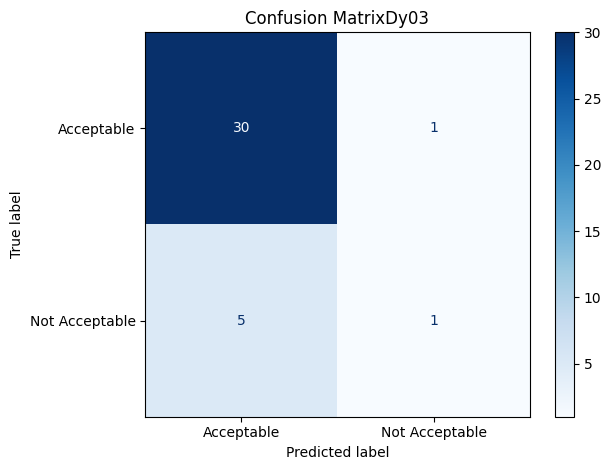

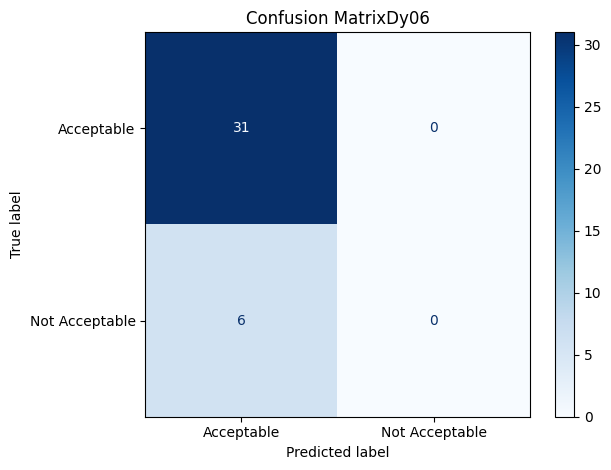

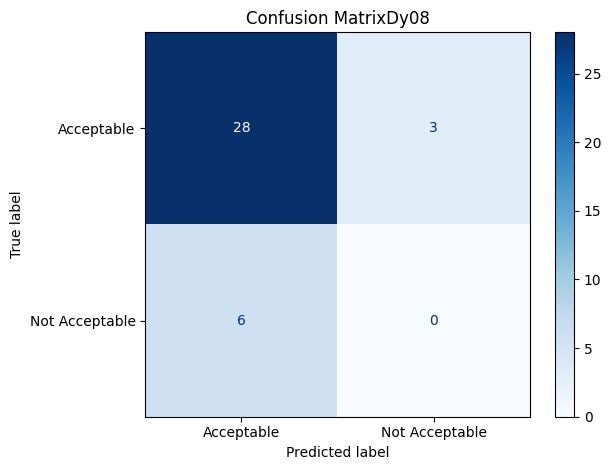

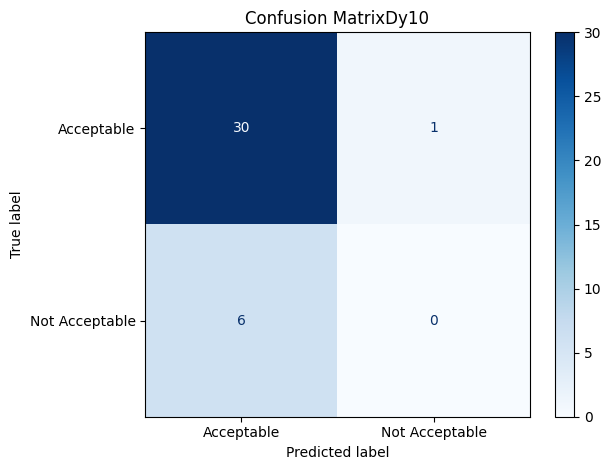

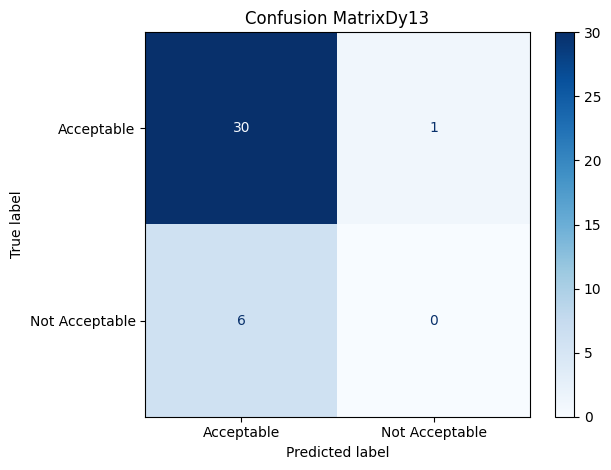

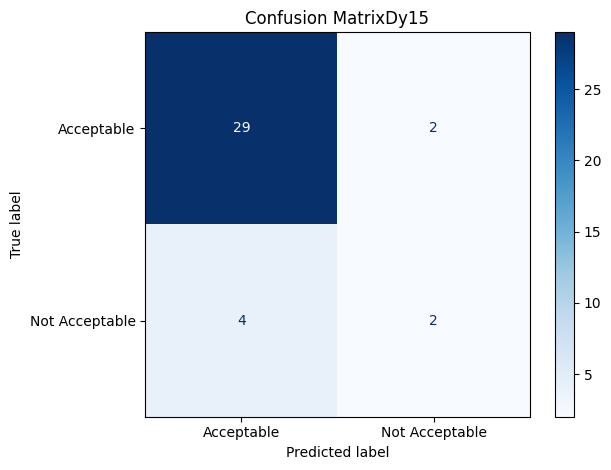

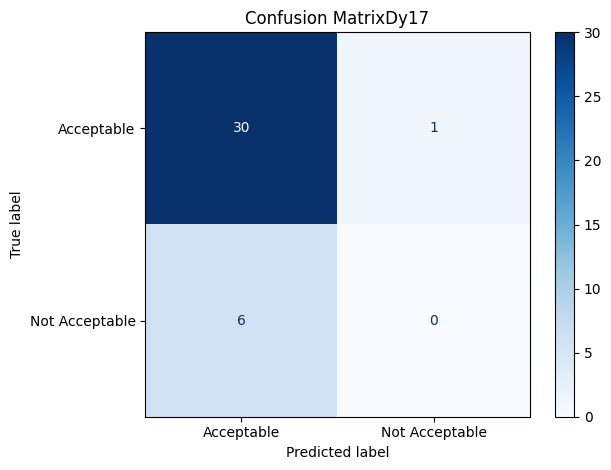

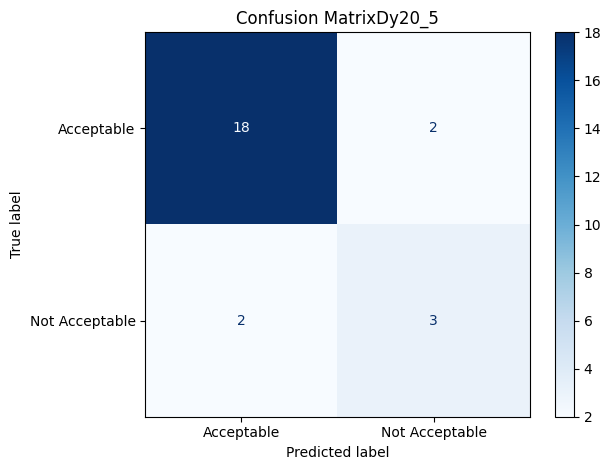

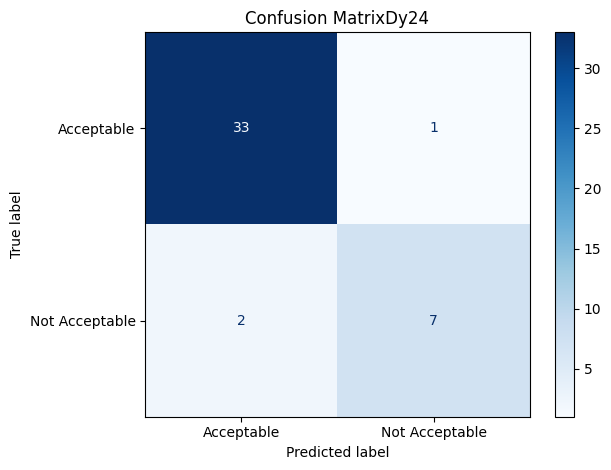

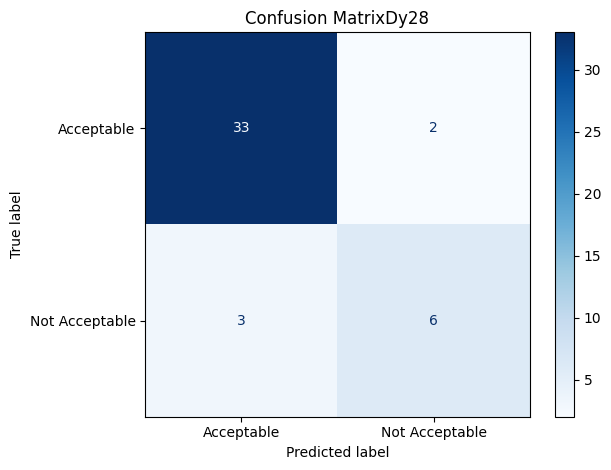

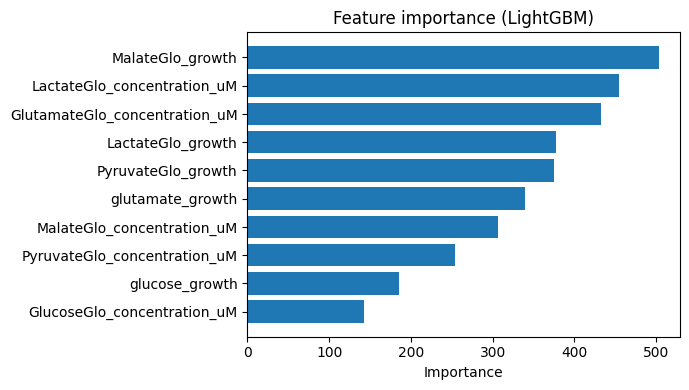

392     BA1 96_1 C7
281    BA2 96_1 A12
Name: ID, dtype: object
Accuracy: 0.9545454545454546
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.95      1.00      0.97        35
Not Acceptable       1.00      0.78      0.88         9

      accuracy                           0.95        44
     macro avg       0.97      0.89      0.92        44
  weighted avg       0.96      0.95      0.95        44

Precision:
 0.9459459459459459
Recall:
 1.0
F1 score:
 0.9722222222222222


/tmp/ipykernel_2653904/3789628107.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


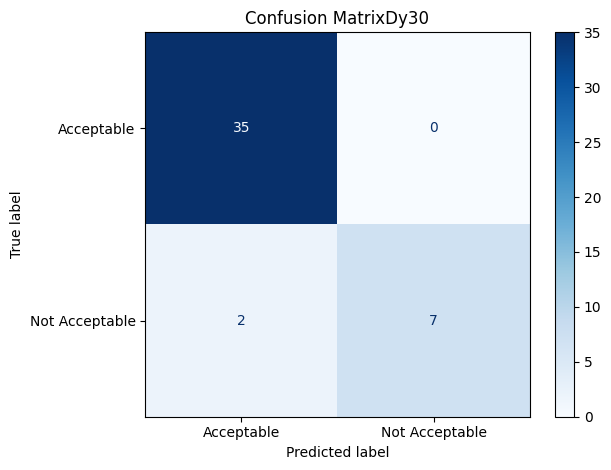

In [37]:
output_df = metabolite_classifier(trainval, test_df, methodstr= "lgbm")

In [38]:
output_df

,DY,accuracy_score_value,precision_accept,precision_notaccept,recall_accept,recall_notaccept,f1-score_accept,f1-score_notaccept
0,Dy03,0.837838,0.857143,0.500,0.967742,0.166667,0.909091,0.250000
1,Dy06,0.837838,0.837838,0.000,1.000000,0.000000,0.911765,0.000000
2,Dy08,0.756757,0.823529,0.000,0.903226,0.000000,0.861538,0.000000
3,Dy10,0.810811,0.833333,0.000,0.967742,0.000000,0.895522,0.000000
4,Dy13,0.810811,0.833333,0.000,0.967742,0.000000,0.895522,0.000000
5,Dy15,0.837838,0.878788,0.500,0.935484,0.333333,0.906250,0.400000
6,Dy17,0.810811,0.833333,0.000,0.967742,0.000000,0.895522,0.000000
7,Dy20_5,0.840000,0.900000,0.600,0.900000,0.600000,0.900000,0.600000
8,Dy24,0.930233,0.942857,0.875,0.970588,0.777778,0.956522,0.823529
9,Dy28,0.886364,0.916667,0.750,0.942857,0.666667,0.929577,0.705882


In [39]:
output_df.to_csv('LGBM_growth.csv')

Dy03
ROC AUC: 0.6317204301075269
Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300}
383     BA1 96_1 C7
271    BA2 96_1 A12
238     BA2 96_1 B3
350     BA2 96_1 B8
393     BA2 96_1 E9
117     BA2 96_2 B6
227     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.97      0.90        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.81        37
     macro avg       0.42      0.48      0.45        37
  weighted avg       0.70      0.81      0.75        37

Precision:
 0.8333333333333334
Recall:
 0.967741935483871
F1 score:
 0.8955223880597015
Dy06


/tmp/ipykernel_2653904/147917375.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ROC AUC: 0.6935483870967741
Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300}
384     BA1 96_1 C7
272    BA2 96_1 A12
239     BA2 96_1 B3
351     BA2 96_1 B8
394     BA2 96_1 E9
228     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.84        37
     macro avg       0.42      0.50      0.46        37
  weighted avg       0.70      0.84      0.76        37

Precision:
 0.8378378378378378
Recall:
 1.0
F1 score:
 0.9117647058823529
Dy08


/tmp/ipykernel_2653904/147917375.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

ROC AUC: 0.5940860215053764
Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 1000}
385     BA1 96_1 C7
273    BA2 96_1 A12
240     BA2 96_1 B3
352     BA2 96_1 B8
251     BA2 96_1 E2
395     BA2 96_1 E9
229     BA2 96_2 G4
Name: ID, dtype: object
Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.97      0.90        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.81        37
     macro avg       0.42      0.48      0.45        37
  weighted avg       0.70      0.81      0.75        37

Precision:
 0.8333333333333334
Recall:
 0.967741935483871
F1 score:
 0.8955223880597015
Dy10


...

/tmp/ipykernel_2653904/147917375.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


ROC AUC: 0.6063492063492063
Best Params: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 1000}
391     BA1 96_1 C7
280    BA2 96_1 A12
402     BA2 96_1 E9
312    BA2 96_1 F10
Name: ID, dtype: object
Accuracy: 0.9090909090909091
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.97      0.94        35
Not Acceptable       0.86      0.67      0.75         9

      accuracy                           0.91        44
     macro avg       0.89      0.82      0.85        44
  weighted avg       0.91      0.91      0.90        44

Precision:
 0.918918918918919
Recall:
 0.9714285714285714
F1 score:
 0.9444444444444444
Dy30


/tmp/ipykernel_2653904/147917375.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


ROC AUC: 0.638095238095238
Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300}
392    BA1 96_1 C7
Name: ID, dtype: object
Accuracy: 0.9772727272727273
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.97      1.00      0.99        35
Not Acceptable       1.00      0.89      0.94         9

      accuracy                           0.98        44
     macro avg       0.99      0.94      0.96        44
  weighted avg       0.98      0.98      0.98        44

Precision:
 0.9722222222222222
Recall:
 1.0
F1 score:
 0.9859154929577465


/tmp/ipykernel_2653904/147917375.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


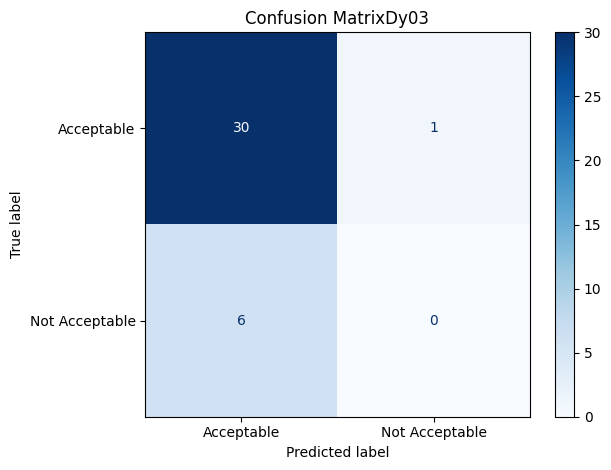

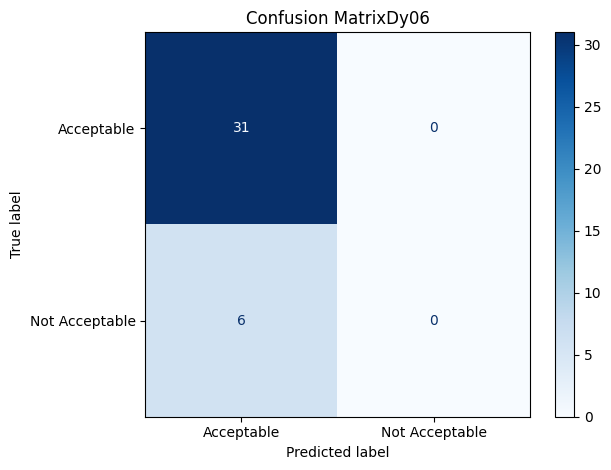

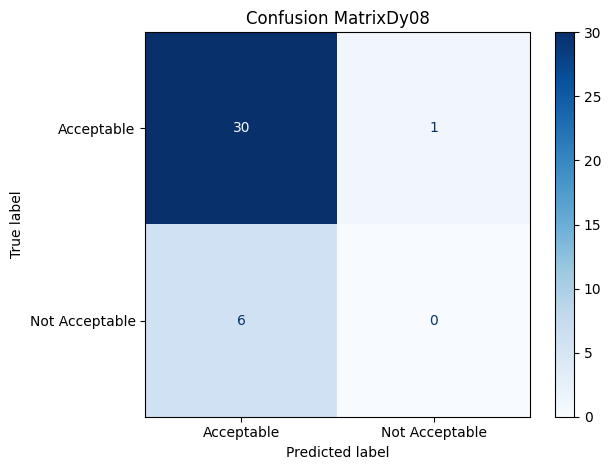

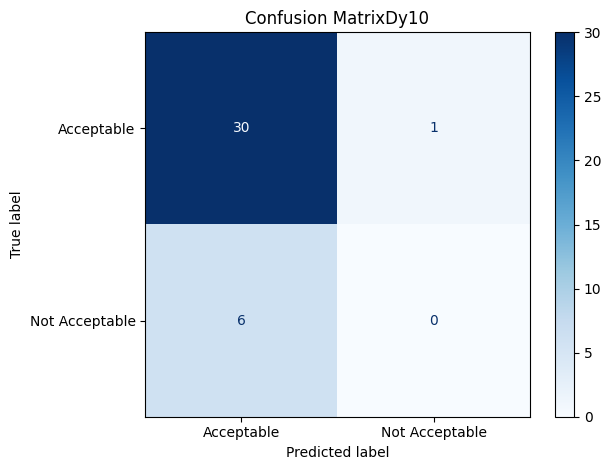

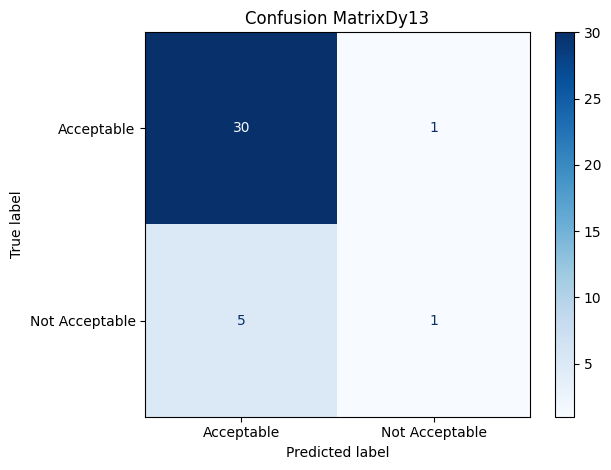

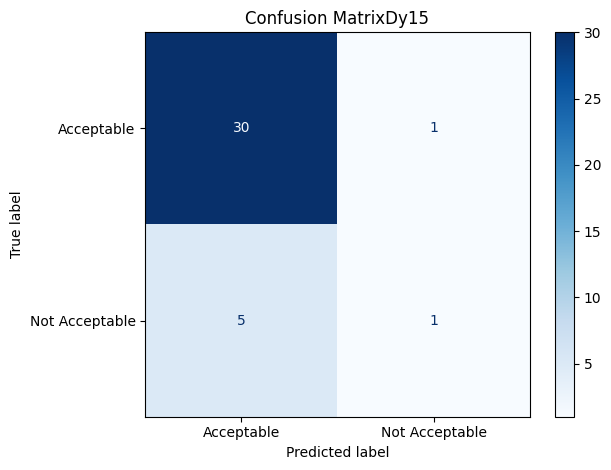

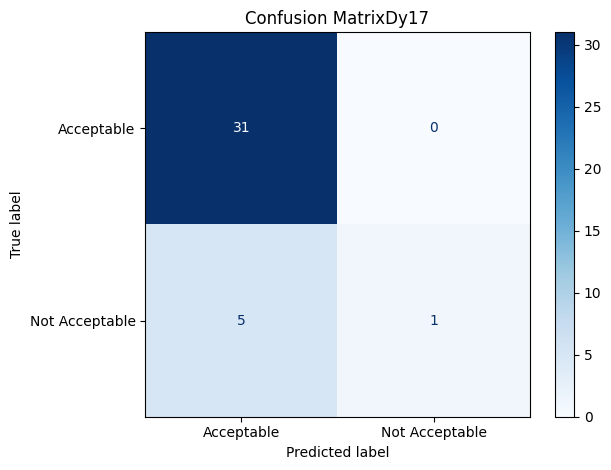

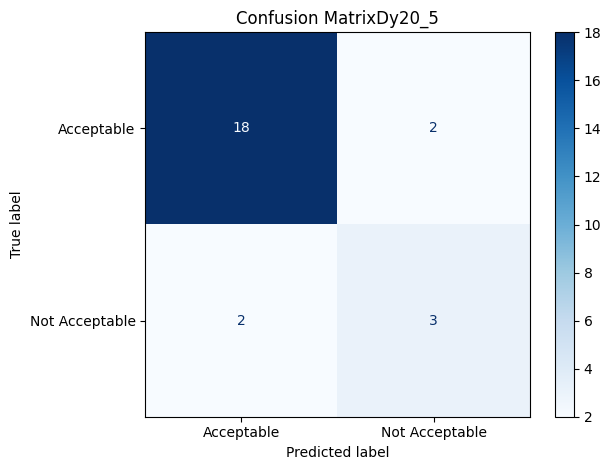

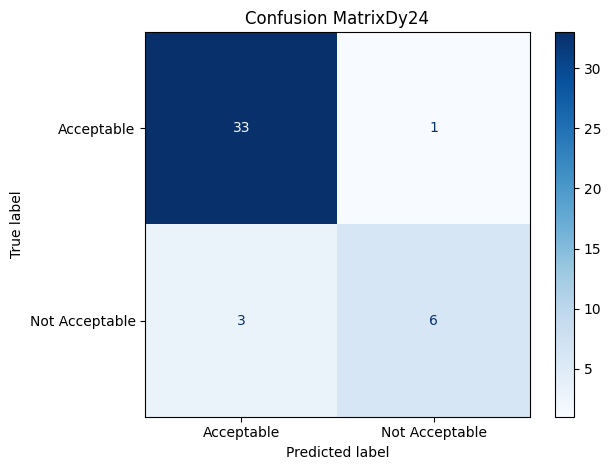

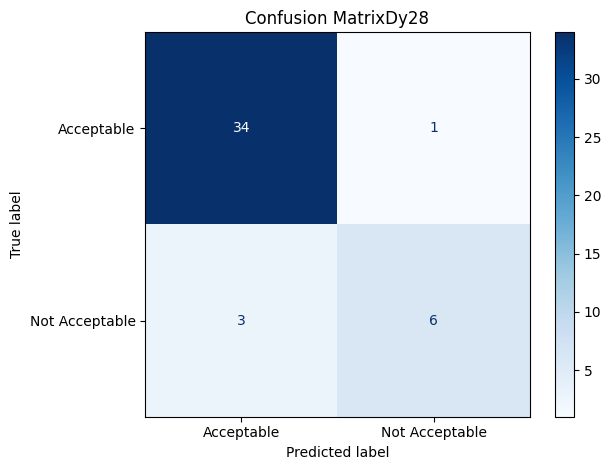

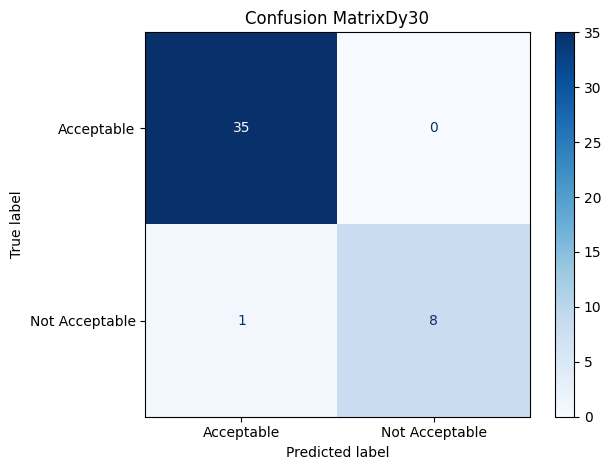

In [26]:
metabolite_classifier(trainval, test_df, methodstr= "rf")

Dy03
ROC AUC: 0.7419354838709676
227     BA2 96_2 G4
238     BA2 96_1 B3
271    BA2 96_1 A12
350     BA2 96_1 B8
383     BA1 96_1 C7
393     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.84        37
     macro avg       0.42      0.50      0.46        37
  weighted avg       0.70      0.84      0.76        37

Precision:
 0.8378378378378378
Recall:
 1.0
F1 score:
 0.9117647058823529
Dy06
ROC AUC: 0.6451612903225806
228     BA2 96_2 G4
239     BA2 96_1 B3
272    BA2 96_1 A12
351     BA2 96_1 B8
384     BA1 96_1 C7
394     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31
Not Acceptable

/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Dy13
ROC AUC: 0.7258064516129031
242     BA2 96_1 B3
275    BA2 96_1 A12
296     BA2 96_2 E6
354     BA2 96_1 B8
387     BA1 96_1 C7
397     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.86      0.97      0.91        31
Not Acceptable       0.50      0.17      0.25         6

      accuracy                           0.84        37
     macro avg       0.68      0.57      0.58        37
  weighted avg       0.80      0.84      0.80        37

Precision:
 0.8571428571428571
Recall:
 0.967741935483871
F1 score:
 0.9090909090909091
Dy15
ROC AUC: 0.7688172043010753
232     BA2 96_2 G4
243     BA2 96_1 B3
276    BA2 96_1 A12
355     BA2 96_1 B8
388     BA1 96_1 C7
398     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31


/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

ROC AUC: 0.7300000000000001
234     BA2 96_2 G4
278    BA2 96_1 A12
400     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.88
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.87      1.00      0.93        20
Not Acceptable       1.00      0.40      0.57         5

      accuracy                           0.88        25
     macro avg       0.93      0.70      0.75        25
  weighted avg       0.90      0.88      0.86        25

Precision:
 0.8695652173913043
Recall:
 1.0
F1 score:
 0.9302325581395349
Dy24
ROC AUC: 0.7614379084967321
97            BA2 96_2 E10
159    BA2 96_1 E8 split_1
279           BA2 96_1 A12
314    BA2 96_2 B3 split_2
358            BA2 96_1 B8
390            BA1 96_1 C7
401            BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8372093023255814
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.85      0.97      0.90        34
Not Acceptable       0.7

/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred
/tmp/ipykernel_4147144/1409753086.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

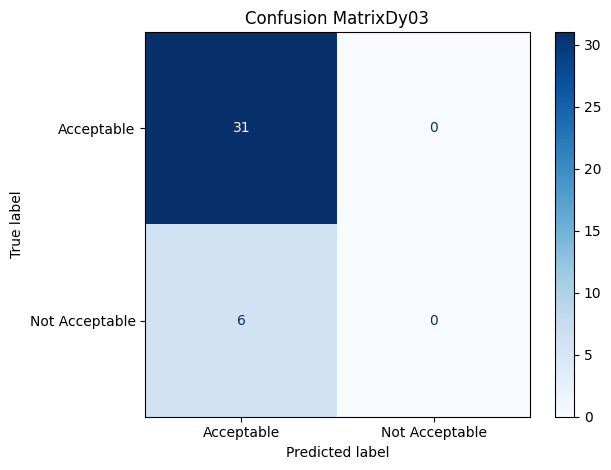

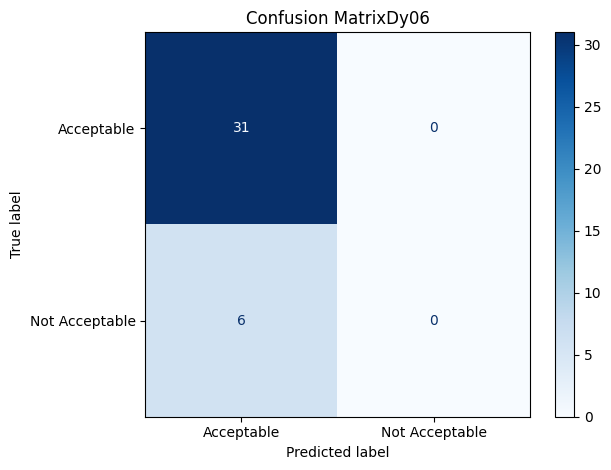

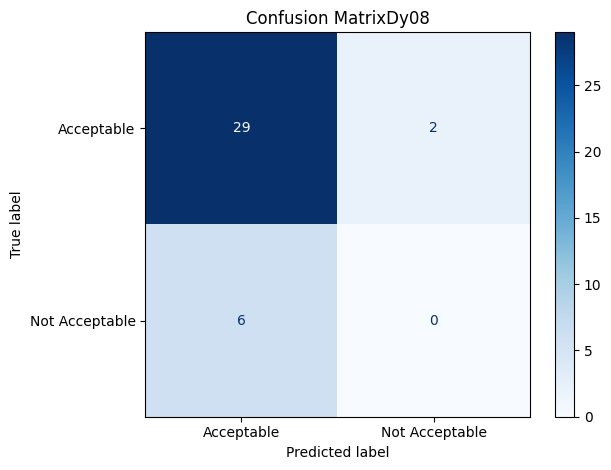

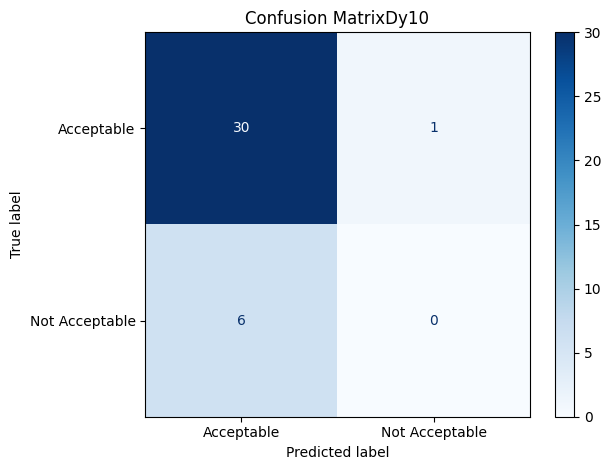

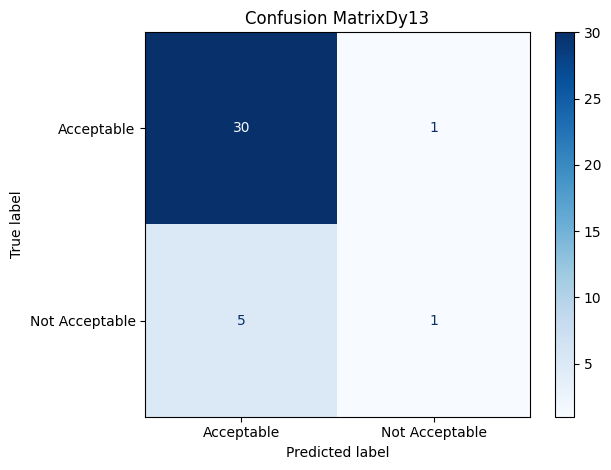

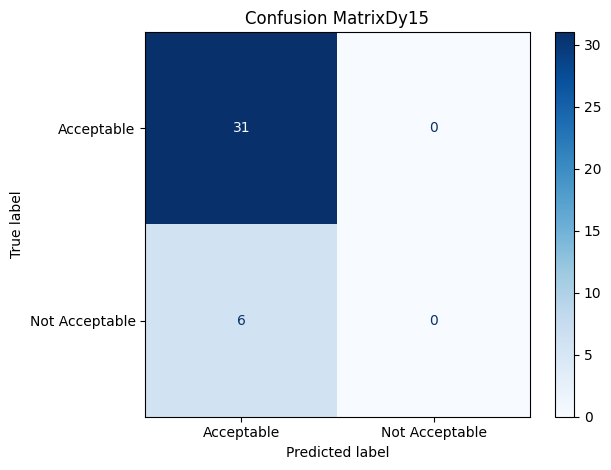

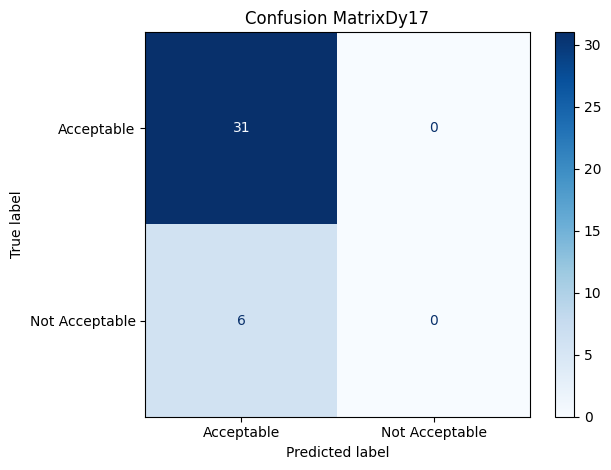

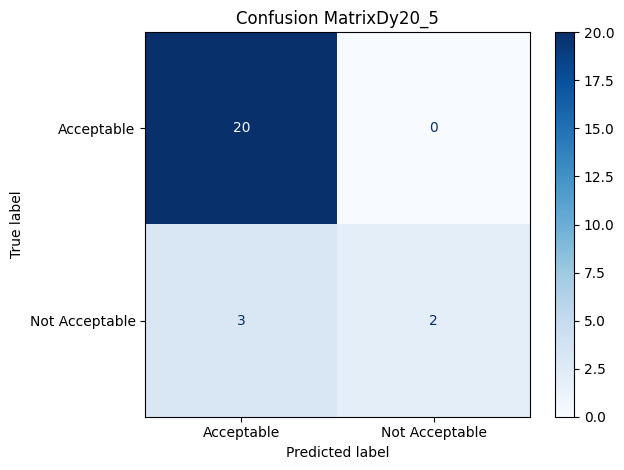

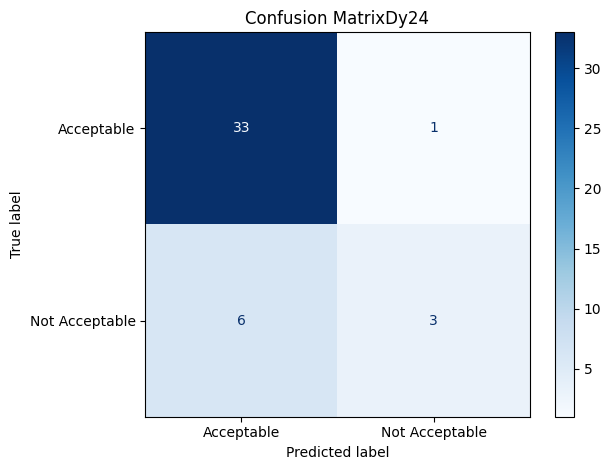

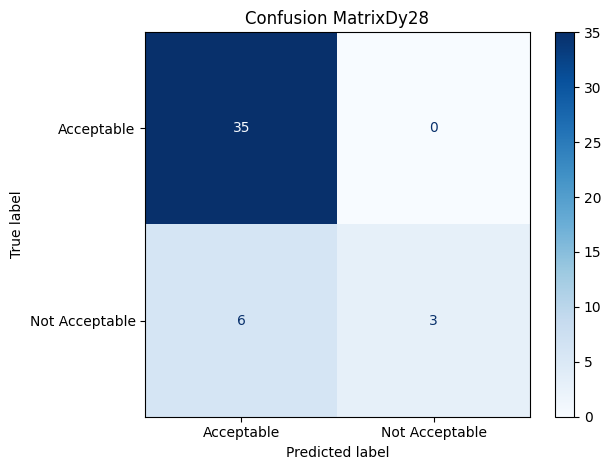

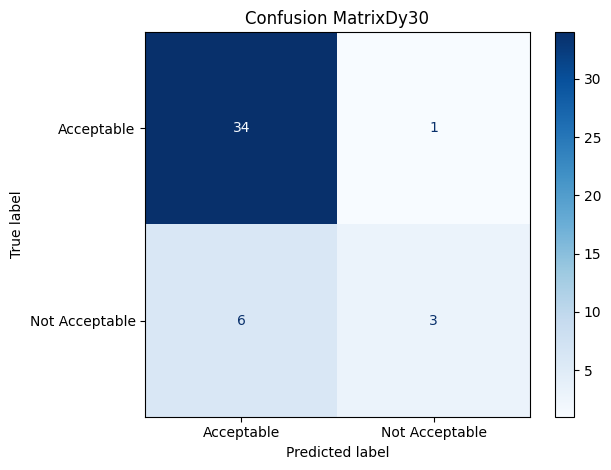

In [51]:
metabolite_classifier(trainval, test_df, methodstr= "LR")